# C1 BiLSTM Hyperparameter Tuning

Focused tuning of the BiLSTM C1 classifier (single vs pileup), using a reduced 64-configuration search space chosen from the earlier broad random search.

## What this notebook does

1. Loads the balanced single + pileup dataset (clean singles and synthetic pileups)
2. Splits into train (60%) / val (20%) / test — the test set is not used during the search
3. Evaluates the focused 64-configuration architecture and optimization grid
4. For each trial, records training history, train/val loss + accuracy, and a per-trial overfit boolean `is_overfit`
5. Ranks trials by a val-only composite score, excluding overfit trials
6. Re-trains the top-ranked configuration from scratch, evaluates it once on the held-out test set, and saves a loss-versus-epochs plot

## Hyperparameters explored

- `lstm_units` — units per direction in each BiLSTM layer: 32 or 64
- `n_lstm_layers` — fixed at 2 in this focused sweep
- `dense_units` — width of the dense layer after the LSTMs: 32 or 64
- `dropout` — dropout in LSTM and dense layers: 0.1 or 0.2
- `learning_rate` — 1e-3 or 2e-3
- `batch_size` — 256 or 512
- `optimizer` — Adam or AdamW

## Overfit safeguards

- **Per-trial:** `overfit_gap = train_acc - val_acc`. Trials with `gap > 0.05` are flagged and excluded from the rankings.
- **Selection bias:** the composite score uses only validation metrics. The test set is held out completely until the very end.

In [1]:
import itertools
import random
import time

import numpy as np
import pandas as pd
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776673123.985948   16624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776673124.699079   16624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load and split data

Singles come from `processed_waveforms.npz`, restricted to `clean_indices` (the singles never used in pileup generation). Pileups come from `pileup_waveforms.npz`. We balance the two classes, apply per-waveform min-max normalization to `[0, 1]`, and split 60/20/20.

In [2]:
singles = np.load("processed_waveforms.npz")
X_singles_all = singles["X_voltage"].astype(np.float32)

pileups = np.load("pileup_waveforms.npz")
X_pileup = pileups["pileup_wf"].astype(np.float32)
n_pileup = X_pileup.shape[0]

clean_idx = pileups["clean_indices"]
X_singles = X_singles_all[clean_idx]
n_singles = X_singles.shape[0]

rng = np.random.default_rng(42)
n_balanced = min(n_singles, n_pileup)
single_idx = rng.choice(n_singles, size=n_balanced, replace=False)
pileup_idx = rng.choice(n_pileup, size=n_balanced, replace=False)

X_all = np.concatenate([X_singles[single_idx], X_pileup[pileup_idx]], axis=0)
y_all = np.concatenate([
    np.zeros(n_balanced, dtype=np.int64),  # 0 = single
    np.ones(n_balanced, dtype=np.int64),   # 1 = pileup
])

# Min-max normalize each waveform independently to [0, 1]
mins = X_all.min(axis=1, keepdims=True)
maxs = X_all.max(axis=1, keepdims=True)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
X_all = (X_all - mins) / ranges

# Shuffle
shuffle = rng.permutation(len(y_all))
X_all = X_all[shuffle]
y_all = y_all[shuffle]

# 60/20/20 train/val/test split
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv
)

# Keras LSTM expects (batch, timesteps, features)
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Class balance (train): single={(y_train==0).sum():,}  pileup={(y_train==1).sum():,}")

Train: (208002, 104, 1)  Val: (69335, 104, 1)  Test: (69335, 104, 1)
Class balance (train): single=104,001  pileup=104,001


## Search space

In [3]:
SEARCH_SPACE = {
    "lstm_units":    [32, 64],
    "n_lstm_layers": [2],
    "dense_units":   [32, 64],
    "dropout":       [0.1, 0.2],
    "learning_rate": [1e-3, 2e-3],
    "batch_size":    [256, 512],
    "optimizer":     ["adam", "adamw"],
}

N_TRIALS   = 64
MAX_EPOCHS = 100
PATIENCE   = 6

# Maximum train_acc - val_acc before flagging a trial as overfit
OVERFIT_GAP_THRESHOLD = 0.05

total_combos = 1
for v in SEARCH_SPACE.values():
    total_combos *= len(v)
print(f"Total possible combos: {total_combos:,}")
print(f"Planned evaluations: {min(N_TRIALS, total_combos):,}")

Total possible combos: 64
Planned evaluations: 64


## Model builder

In [4]:
def get_optimizer(name, learning_rate):
    if name == "adam":  return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adamw": return keras.optimizers.AdamW(learning_rate=learning_rate)
    if name == "nadam": return keras.optimizers.Nadam(learning_rate=learning_rate)
    raise ValueError(f"Unknown optimizer: {name}")


def build_bilstm(hp, n_samples=104):
    model_layers = [keras.layers.Input(shape=(n_samples, 1))]
    for i in range(hp["n_lstm_layers"]):
        return_seq = (i < hp["n_lstm_layers"] - 1)
        model_layers.append(
            layers.Bidirectional(
                layers.LSTM(
                    hp["lstm_units"],
                    return_sequences=return_seq,
                    dropout=hp["dropout"],
                )
            )
        )
    model_layers.append(layers.Dense(hp["dense_units"], activation="relu"))
    model_layers.append(layers.Dropout(hp["dropout"]))
    model_layers.append(layers.Dense(1, activation="sigmoid"))

    model = keras.Sequential(model_layers)
    model.compile(
        optimizer=get_optimizer(hp["optimizer"], hp["learning_rate"]),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


## Trial evaluation

Each trial trains a model on the train split, with early stopping monitored on `val_loss`. After training:

1. Re-measure train and val accuracy/loss
2. Compute `overfit_gap = train_acc - val_acc`
3. Compute `composite_score = 0.5 * val_loss + 0.5 * (1 - val_acc)` (val-only)
4. Save the full training history so we can plot loss curves later

The test set is not touched at this stage.

In [5]:
def composite_score(val_loss, val_acc, alpha=0.5):
    return alpha * val_loss + (1 - alpha) * (1 - val_acc)


def run_trial(hp, X_train, X_val, y_train, y_val,
              max_epochs=MAX_EPOCHS, patience=PATIENCE):
    keras.backend.clear_session()
    model = build_bilstm(hp, n_samples=X_train.shape[1])
    n_params = model.count_params()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience,
            restore_best_weights=True, verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", patience=3, factor=0.5, verbose=0,
        ),
    ]

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=hp["batch_size"],
        callbacks=callbacks,
        verbose=1,
    )
    train_time = time.time() - t0

    # Re-measure on train + val after early stopping has restored best weights
    train_loss, train_acc = model.evaluate(X_train, y_train, batch_size=hp["batch_size"], verbose=0)
    val_loss,   val_acc   = model.evaluate(X_val,   y_val,   batch_size=hp["batch_size"], verbose=0)

    overfit_gap = train_acc - val_acc
    is_overfit = overfit_gap > OVERFIT_GAP_THRESHOLD
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    return {
        **hp,
        "n_params": n_params,
        "best_epoch": best_epoch,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "overfit_gap": float(overfit_gap),
        "is_overfit": bool(is_overfit),
        "composite_score": float(composite_score(val_loss, val_acc)),
        "train_time_s": round(train_time, 1),
    }, history.history

## Run the focused search

Histories are kept in memory (a list of dicts) so we can plot loss curves for the top 3 later. The summary results are saved incrementally to `C1_Tune_Results.csv`.

In [ ]:
import os

results_path = "C1_Tune_Results.csv"
all_combos = list(itertools.product(*SEARCH_SPACE.values()))
keys = list(SEARCH_SPACE.keys())
configs = all_combos if len(all_combos) <= N_TRIALS else random.sample(all_combos, N_TRIALS)

if os.path.exists(results_path):
    existing_df = pd.read_csv(results_path)
    results = existing_df.to_dict("records")
    completed_keys = {
        (
            int(r["lstm_units"]),
            int(r["n_lstm_layers"]),
            int(r["dense_units"]),
            float(r["dropout"]),
            float(r["learning_rate"]),
            int(r["batch_size"]),
            str(r["optimizer"]),
        )
        for r in results
    }
    print(f"Resuming from {results_path}: {len(results)} completed trials")
else:
    results = []
    completed_keys = set()
    print(f"Starting fresh: {results_path}")

histories = [None] * len(results)  # earlier trials were loaded from CSV

for trial_num, combo in enumerate(configs):
    hp = dict(zip(keys, combo))
    key = (
        hp["lstm_units"],
        hp["n_lstm_layers"],
        hp["dense_units"],
        hp["dropout"],
        hp["learning_rate"],
        hp["batch_size"],
        hp["optimizer"],
    )
    if key in completed_keys:
        print(f"\nTrial {trial_num+1}/{len(configs)}: SKIP (already done) {hp}")
        continue

    print(f"\n{'='*78}")
    print(f"Trial {trial_num+1}/{len(configs)}")
    print(f"  arch: lstm={hp['lstm_units']} layers={hp['n_lstm_layers']} dense={hp['dense_units']} drop={hp['dropout']}")
    print(f"  opt:  {hp['optimizer']} lr={hp['learning_rate']} bs={hp['batch_size']}")

    try:
        result, history = run_trial(hp, X_train, X_val, y_train, y_val)
        results.append(result)
        histories.append(history)
        completed_keys.add(key)
        flag = " [OVERFIT]" if result["is_overfit"] else ""
        print(f"  -> train_acc={result['train_acc']:.4f}  val_acc={result['val_acc']:.4f}  "
              f"gap={result['overfit_gap']:+.4f}{flag}  "
              f"score={result['composite_score']:.5f}  "
              f"params={result['n_params']:,}  time={result['train_time_s']}s")
    except Exception as e:
        print(f"  -> FAILED: {e}")
        continue

    # Incremental save (summary only, the histories are in memory)
    pd.DataFrame(results).to_csv(results_path, index=False)

n_overfit = sum(1 for r in results if r['is_overfit'])
print(f"\n{'='*78}")
print(f"Complete: {len(results)}/{len(configs)} successful, {n_overfit} flagged as overfit")

Resuming from C1_Tune_Results.csv: 37 completed trials

Trial 1/64: SKIP (already done) {'lstm_units': 32, 'n_lstm_layers': 2, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 256, 'optimizer': 'adam'}

Trial 2/64: SKIP (already done) {'lstm_units': 32, 'n_lstm_layers': 2, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 256, 'optimizer': 'adamw'}

Trial 3/64: SKIP (already done) {'lstm_units': 32, 'n_lstm_layers': 2, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 512, 'optimizer': 'adam'}

Trial 4/64: SKIP (already done) {'lstm_units': 32, 'n_lstm_layers': 2, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 512, 'optimizer': 'adamw'}

Trial 5/64: SKIP (already done) {'lstm_units': 32, 'n_lstm_layers': 2, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.002, 'batch_size': 256, 'optimizer': 'adam'}

Trial 6/64: SKIP (already done) {'lstm_units': 32, 'n_lstm_layers': 2, 'dense_units': 3

I0000 00:00:1776673126.792072   16624 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11552 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Epoch 1/100


I0000 00:00:1776673129.282644   16801 cuda_dnn.cc:461] Loaded cuDNN version 91900


813/813 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9013 - loss: 0.2308 - val_accuracy: 0.9352 - val_loss: 0.1625 - learning_rate: 0.0020
Epoch 2/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9341 - loss: 0.1645 - val_accuracy: 0.9523 - val_loss: 0.1286 - learning_rate: 0.0020
Epoch 3/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9495 - loss: 0.1331 - val_accuracy: 0.9641 - val_loss: 0.1032 - learning_rate: 0.0020
Epoch 4/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9553 - loss: 0.1198 - val_accuracy: 0.9632 - val_loss: 0.1039 - learning_rate: 0.0020
Epoch 5/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9592 - loss: 0.1121 - val_accuracy: 0.9681 - val_loss: 0.0944 - learning_rate: 0.0020
Epoch 6/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9588 - loss: 0.1112 - val_accuracy: 0.9610 - val_loss: 0.1060 - learning_rate: 0.0020
Epoch 7/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9605 - loss: 

## Top configurations (overfit excluded)

In [ ]:
df = pd.DataFrame(results)
print(f"Total trials: {len(df)}")
print(f"Overfit trials excluded: {df['is_overfit'].sum()}")
print(f"Eligible trials: {(~df['is_overfit']).sum()}")
print()

clean_df = df[~df["is_overfit"]].copy()

print("=" * 100)
print("TOP 10 BY COMPOSITE SCORE (overfit excluded)")
print("=" * 100)
cols = ["lstm_units", "n_lstm_layers", "dense_units", "dropout",
        "learning_rate", "batch_size", "optimizer",
        "train_acc", "val_acc", "overfit_gap", "composite_score", "n_params", "best_epoch"]
print(clean_df.sort_values("composite_score").head(10)[cols].to_string())

print("\n\nFull comparison: clean vs overfit")
# print("=" * 60)
# if df['is_overfit'].any():
#     summary = df.groupby("is_overfit").agg(
#         n=("composite_score", "count"),
#         mean_train_acc=("train_acc", "mean"),
#         mean_val_acc=("val_acc", "mean"),
#         mean_overfit_gap=("overfit_gap", "mean"),
#         best_score=("composite_score", "min"),
#     )
#     print(summary.round(4).to_string())

Total trials: 64
Overfit trials excluded: 0
Eligible trials: 64

TOP 10 BY COMPOSITE SCORE (overfit excluded)
    lstm_units  n_lstm_layers  dense_units  dropout  learning_rate  batch_size optimizer  train_acc   val_acc  overfit_gap  composite_score  n_params  best_epoch
52          64              2           64      0.1          0.002         256      adam   0.979096  0.978178     0.000918         0.044198    140929          37
36          64              2           32      0.1          0.002         256      adam   0.978519  0.977789     0.000730         0.045011    136769          29
38          64              2           32      0.1          0.002         512      adam   0.978688  0.977977     0.000711         0.045091    136769          39
53          64              2           64      0.1          0.002         256     adamw   0.978462  0.977616     0.000846         0.045333    140929          23
5           32              2           32      0.1          0.002         256  

## Per-hyperparameter effects

How each hyperparameter individually affects validation accuracy. Red dots = means

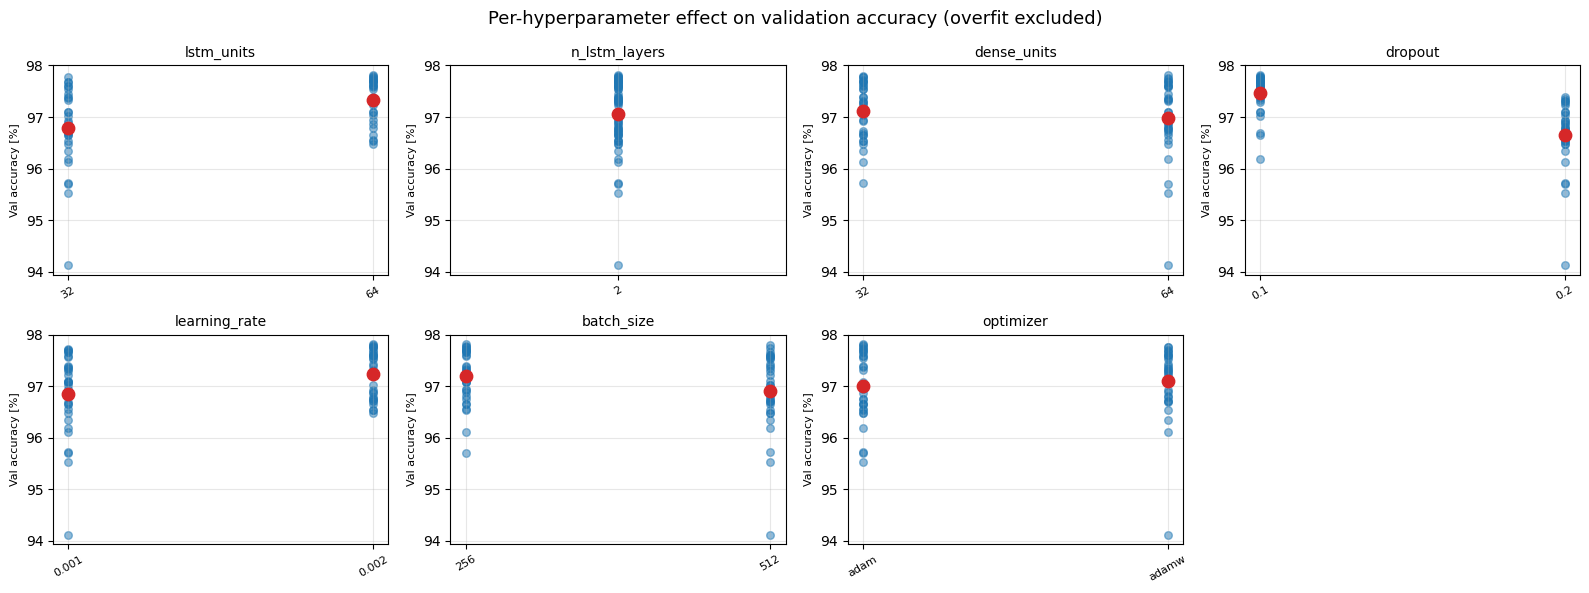

In [8]:
import os; os.makedirs("figures", exist_ok=True)
hp_to_plot = list(SEARCH_SPACE.keys())
ncols = 4
nrows = int(np.ceil(len(hp_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, hp_name in zip(axes, hp_to_plot):
    vals = clean_df[hp_name].astype(str)
    unique = sorted(vals.unique())
    for v in unique:
        mask = vals == v
        ax.scatter([v] * mask.sum(),
                   clean_df.loc[mask, "val_acc"].values * 100,
                   alpha=0.5, s=30, color="tab:blue")
    means = clean_df.groupby(vals)["val_acc"].mean() * 100
    ax.scatter(means.index, means.values, color="tab:red", s=80, zorder=5, label="Mean")
    ax.set_title(hp_name, fontsize=10)
    ax.set_ylabel("Val accuracy [%]", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(hp_to_plot), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Per-hyperparameter effect on validation accuracy (overfit excluded)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/c1_tune_hyperparameter_effects.png", dpi=120, bbox_inches="tight")
plt.show()

## Test-set evaluation of the top-ranked configuration


Top-ranked config: lstm=64 layers=2 dense=64 drop=0.1 lr=0.002 bs=256 adam
  val_acc (search) = 0.9782
Epoch 1/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8656 - loss: 0.2803 - val_accuracy: 0.9352 - val_loss: 0.1621 - learning_rate: 0.0020
Epoch 2/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8876 - loss: 0.2303 - val_accuracy: 0.9200 - val_loss: 0.1916 - learning_rate: 0.0020
Epoch 3/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8961 - loss: 0.2092 - val_accuracy: 0.9493 - val_loss: 0.1328 - learning_rate: 0.0020
Epoch 4/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9071 - loss: 0.1867 - val_accuracy: 0.9609 - val_loss: 0.1086 - learning_rate: 0.0020
Epoch 5/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9143 - loss: 0.1737 - val_accuracy: 0.9508 - val_loss: 0.1348 - learning_rate: 0.0020
Epoch 6/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9520 - loss: 0.1286 - val_accuracy: 0.9626 - val_loss

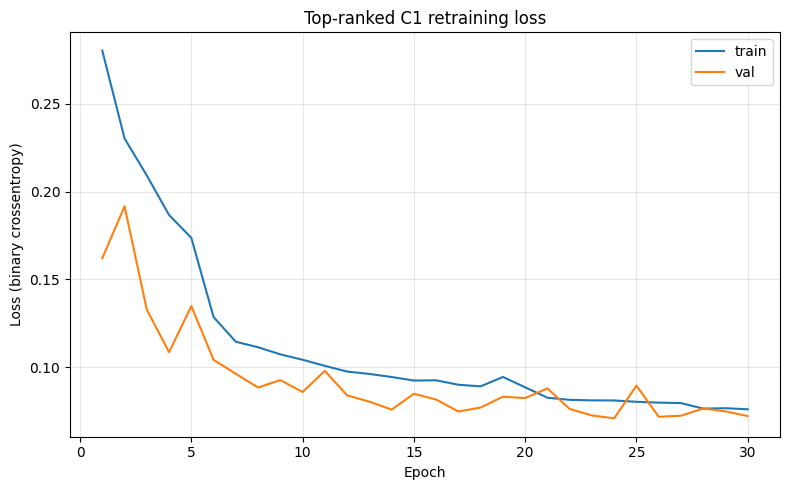


Saved C1_Tune_Results.csv and c1_tune_finalists.csv


In [10]:
top1 = clean_df.sort_values("composite_score").head(1)
final_results = []

row = top1.iloc[0]
hp = {k: row[k] for k in SEARCH_SPACE.keys()}
# Cast back to native types
hp["lstm_units"]    = int(hp["lstm_units"])
hp["n_lstm_layers"] = int(hp["n_lstm_layers"])
hp["dense_units"]   = int(hp["dense_units"])
hp["batch_size"]    = int(hp["batch_size"])
hp["dropout"]       = float(hp["dropout"])
hp["learning_rate"] = float(hp["learning_rate"])

print(f"Top-ranked config: lstm={hp['lstm_units']} layers={hp['n_lstm_layers']} "
      f"dense={hp['dense_units']} drop={hp['dropout']} lr={hp['learning_rate']} "
      f"bs={hp['batch_size']} {hp['optimizer']}")
print(f"  val_acc (search) = {row.val_acc:.4f}")

keras.backend.clear_session()
model = build_bilstm(hp, n_samples=X_train.shape[1])
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                   restore_best_weights=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=0),
]
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=MAX_EPOCHS, batch_size=hp["batch_size"],
                    callbacks=callbacks, verbose=1)

test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=hp["batch_size"], verbose=0)
val_test_gap = test_acc - row.val_acc

print(f"  test_acc         = {test_acc:.4f}")
print(f"  val -> test gap  = {val_test_gap:+.4f}")

final_results.append({
    "rank": 1,
    "lstm_units": hp["lstm_units"],
    "n_lstm_layers": hp["n_lstm_layers"],
    "dense_units": hp["dense_units"],
    "dropout": hp["dropout"],
    "learning_rate": hp["learning_rate"],
    "batch_size": hp["batch_size"],
    "optimizer": hp["optimizer"],
    "val_acc": row.val_acc,
    "test_acc": float(test_acc),
    "val_test_gap": float(val_test_gap),
})

print("\n" + "=" * 70)
print("TOP-RANKED FINALIST SUMMARY")
print("=" * 70)
final_df = pd.DataFrame(final_results)
print(final_df.to_string(index=False))

plt.figure(figsize=(8, 5))
epochs = np.arange(1, len(history.history["loss"]) + 1)
plt.plot(epochs, history.history["loss"], label="train", color="tab:blue")
plt.plot(epochs, history.history["val_loss"], label="val", color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Loss (binary crossentropy)")
plt.title("Top-ranked C1 retraining loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/c1_tune_top1_retrain_loss.png", dpi=120, bbox_inches="tight")
plt.show()

df.to_csv("C1_Tune_Results.csv", index=False)
final_df.to_csv("c1_tune_finalists.csv", index=False)
print("\nSaved C1_Tune_Results.csv and c1_tune_finalists.csv")